# NB04 — Comparative Analysis of Anomaly Sets
## BAREKENG MS 21575 — Table 2, Figures 6–7, and Editor Comment E1

**Stage overview.** Reproduces Table 2 (overlap counts and Jaccard index across model
pairs), rebuilds Figures 6 and 7, and adds the mathematical treatment the editor asked for:
the Jaccard index interpreted against a hypergeometric independence baseline rather than
asserted to be "low".

| | |
|---|---|
| **Manuscript link** | §3.2 Visualisation, §3.3 Comparative Analysis, Table 2, Figures 6–7 |
| **Reviewer comments** | **E1** — "deeper mathematical or statistical analysis … e.g. interpretation of Jaccard Index" |
| **Upstream** | NB02 → `summary_NB02.json` |
| **Downstream** | NB05 (consumes the 545-record intersection), NB07 |

### Inputs
| Artifact | Path |
|---|---|
| Handshake | `outputs/notebook_exports/summary_NB02.json` |
| Labels | `data/processed/anomaly_labels.parquet` |
| Features | `data/processed/features_raw.parquet` |

### Outputs
| Artifact | Path |
|---|---|
| Table 2 | `outputs/tables/nb04_table2_jaccard_overlap.csv` |
| Null-model test | `outputs/tables/nb04_jaccard_null_model.csv` |
| Consensus set | `data/processed/consensus_anomalies.parquet` (the 545) |
| Figure 6 | `outputs/figures/nb04_fig6_venn.png` |
| Figure 7 | `outputs/figures/nb04_fig7_contingency.png` |
| Figure (E1) | `outputs/figures/nb04_fig_null_model.png` |
| Handshake | `outputs/notebook_exports/summary_NB04.json` |

---

## The E1 argument

The submitted manuscript reads *J* = 0.058 as evidence that the two algorithms **disagree**.
That inference does not follow. Jaccard is bounded by set size: any two subsets of 5,000
drawn from 100,000 will overlap in roughly 250 records **by chance alone**, giving
*J* ≈ 0.026. A low Jaccard is therefore the expected outcome for small subsets of a large
population and, on its own, carries no information about whether the models agree.

The meaningful question is how the observed overlap compares with that null. Under a
hypergeometric model — the exact distribution for sampling without replacement — this
notebook computes E[|A∩B|], its variance, an exact one-sided p-value, and a bootstrap
confidence interval on *J* itself.

If the observed overlap exceeds the null, the correct reading reverses: the algorithms agree
**more than chance**, while each still retains a large private subset. Complementarity
survives and is better supported, but the wording in §3.3 and the abstract must change.

> ⚠️ **The null model applies to IF vs LOF only.** The two LOF variants are thresholds on a
> single score function, so one is nested inside the other by construction. Testing whether
> they overlap "more than chance" is meaningless, and Cell 07 excludes that pair from the
> inferential claim while still reporting it for completeness.

In [1]:
# Cell 01 — Mount Storage & Define Paths

import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
PROJECT_FOLDER_NAME = "BarekengPaper1-Revision"

if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    BASE = Path(f"/content/drive/MyDrive/{PROJECT_FOLDER_NAME}")
else:
    BASE = Path.cwd()
    if BASE.name == "notebooks":
        BASE = BASE.parent

PROCESSED = BASE / "data" / "processed"
FIGURES = BASE / "outputs" / "figures"
TABLES = BASE / "outputs" / "tables"
EXPORTS = BASE / "outputs" / "notebook_exports"
MANUSCRIPT = BASE / "outputs" / "manuscript_ready"

for d in [PROCESSED, FIGURES, TABLES, EXPORTS, MANUSCRIPT]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Environment : {'Google Colab' if IN_COLAB else 'Local workstation'}")
print(f"Base        : {BASE}")

Mounted at /content/drive
Environment : Google Colab
Base        : /content/drive/MyDrive/BarekengPaper1-Revision


In [2]:
# Cell 02 — Imports, Global Seed, Style & Environment Capture
# matplotlib-venn is not preinstalled on Colab. Version floor matches requirements.txt.

import json
import platform
import subprocess
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from scipy.stats import hypergeom

try:
    import matplotlib_venn
except ImportError:
    print("matplotlib-venn not found; installing...")
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "matplotlib-venn>=0.11.9"],
                   check=True)
    import matplotlib_venn

from matplotlib_venn import venn2

warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    "font.family": "serif", "font.size": 10, "axes.titlesize": 11, "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9, "figure.titlesize": 12,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.3,
})

ENVIRONMENT = {
    "python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__,
    "scipy": scipy.__version__, "matplotlib": matplotlib.__version__, "seaborn": sns.__version__,
    "matplotlib_venn": getattr(matplotlib_venn, "__version__", "unknown"),
}

print(f"Seed fixed to {SEED}.\n")
for pkg, ver in ENVIRONMENT.items():
    print(f"  {pkg:<16} {ver}")

Seed fixed to 42.

  python           3.13.15
  numpy            2.1.3
  pandas           2.2.3
  scipy            1.16.3
  matplotlib       3.10.0
  seaborn          0.13.2
  matplotlib_venn  1.1.2


In [3]:
# Cell 03 — Validate Upstream Handshake (NB02 -> NB04)

UPSTREAM = "NB02"
handshake_path = EXPORTS / f"summary_{UPSTREAM}.json"

if not handshake_path.exists():
    raise FileNotFoundError(f"Missing {handshake_path}. Run {UPSTREAM} first.")

with open(handshake_path, "r", encoding="utf-8") as fh:
    upstream = json.load(fh)

if upstream.get("status") != "SUCCESS":
    raise AssertionError(f"{UPSTREAM} did not report SUCCESS.")
failed = [k for k, v in upstream.get("assertions", {}).items() if not v]
if failed:
    raise AssertionError(f"{UPSTREAM} assertions failed: {failed}")
if not upstream["parity"]["lof_auto_count_2565"]:
    raise AssertionError("NB02 did not reproduce LOF(auto) = 2,565; Table 2 cannot be trusted.")

BASELINE = {
    "IF": upstream["key_results"]["if_anomaly_count"],
    "LOF_auto": upstream["key_results"]["lof_auto_anomaly_count"],
    "LOF_05": upstream["key_results"]["lof_05_anomaly_count"],
}

print(f"Upstream {UPSTREAM} verified (ran {upstream['timestamp']}).")
for k, v in BASELINE.items():
    print(f"  {k:<10}{v:,}")

Upstream NB02 verified (ran 2026-09-20T21:09:53.013235).
  IF        5,000
  LOF_auto  2,565
  LOF_05    5,000


---
## Section 1 — Table 2: Overlap and Jaccard Index (Manuscript §3.3, Equation 5)

In [4]:
# Cell 04 — Load: Anomaly Label Sets

df_labels = pd.read_parquet(PROCESSED / "anomaly_labels.parquet")
df_features = pd.read_parquet(PROCESSED / "features_raw.parquet")

assert len(df_labels) == len(df_features) == 100_000, "Unexpected row count"

N_TOTAL = len(df_labels)
S_IF = set(np.flatnonzero(df_labels["IF_Label"].values == -1))
S_LOF_AUTO = set(np.flatnonzero(df_labels["LOF_Auto_Label"].values == -1))
S_LOF_05 = set(np.flatnonzero(df_labels["LOF_05_Label"].values == -1))

assert len(S_IF) == BASELINE["IF"], "IF set disagrees with the NB02 handshake"
assert len(S_LOF_AUTO) == BASELINE["LOF_auto"], "LOF(auto) set disagrees with the NB02 handshake"
assert len(S_LOF_05) == BASELINE["LOF_05"], "LOF(0.05) set disagrees with the NB02 handshake"

print(f"N = {N_TOTAL:,}")
print(f"  IF          {len(S_IF):,}")
print(f"  LOF(auto)   {len(S_LOF_AUTO):,}")
print(f"  LOF(0.05)   {len(S_LOF_05):,}")

N = 100,000
  IF          5,000
  LOF(auto)   2,565
  LOF(0.05)   5,000


In [5]:
# Cell 05 — Test: Table 2 Overlap Counts and Jaccard Index


def jaccard(a, b):
    return len(a & b) / len(a | b) if (a | b) else 0.0


PAIRS = [
    ("IF vs LOF(auto)", S_IF, S_LOF_AUTO, 341, 0.047),
    ("IF vs LOF(0.05)", S_IF, S_LOF_05, 545, 0.058),
    ("LOF(auto) vs LOF(0.05)", S_LOF_AUTO, S_LOF_05, 2565, 0.513),
]

rows = []
for name, a, b, pub_overlap, pub_j in PAIRS:
    rows.append({
        "Model Pair": name,
        "Set A size": len(a), "Set B size": len(b),
        "Overlap Count": len(a & b),
        "Union": len(a | b),
        "Jaccard Index": round(jaccard(a, b), 5),
        "Published Overlap": pub_overlap,
        "Published Jaccard": pub_j,
    })

table2 = pd.DataFrame(rows)
table2["Parity"] = np.where(table2["Overlap Count"] == table2["Published Overlap"], "match", "MISS")

print(table2.to_string(index=False))

mismatches = table2[table2["Parity"] != "match"]
assert mismatches.empty, f"Table 2 parity failure:\n{mismatches}"

# LOF(auto) must be a strict subset of LOF(0.05): identical scores, stricter threshold.
NESTED = S_LOF_AUTO <= S_LOF_05
assert NESTED, (
    "LOF(auto) is not contained in LOF(0.05). Both are thresholds on the same fitted score "
    "vector, so containment is structural -- a violation means the two runs did not see "
    "identical input."
)

print(f"\nAll three overlap counts match the manuscript.")
print(f"LOF(auto) is a strict subset of LOF(0.05): {NESTED} "
      f"({len(S_LOF_AUTO & S_LOF_05):,} of {len(S_LOF_AUTO):,} shared)")

            Model Pair  Set A size  Set B size  Overlap Count  Union  Jaccard Index  Published Overlap  Published Jaccard Parity
       IF vs LOF(auto)        5000        2565            341   7224        0.04720                341              0.047  match
       IF vs LOF(0.05)        5000        5000            545   9455        0.05764                545              0.058  match
LOF(auto) vs LOF(0.05)        2565        5000           2565   5000        0.51300               2565              0.513  match

All three overlap counts match the manuscript.
LOF(auto) is a strict subset of LOF(0.05): True (2,565 of 2,565 shared)


---
## Section 2 — E1: The Jaccard Index against a Null Model

In [6]:
# Cell 06 — Test: Hypergeometric Independence Baseline
# If A and B were drawn independently, |A n B| ~ Hypergeometric(N, |A|, |B|).

null_rows = []
for name, a, b, _, _ in PAIRS:
    K, n, obs = len(a), len(b), len(a & b)
    expected = n * K / N_TOTAL
    variance = n * (K / N_TOTAL) * ((N_TOTAL - K) / N_TOTAL) * ((N_TOTAL - n) / (N_TOTAL - 1))
    sd = np.sqrt(variance)
    z = (obs - expected) / sd
    p_exact = float(hypergeom.sf(obs - 1, N_TOTAL, K, n))   # P(X >= obs)

    j_obs = obs / (K + n - obs)
    j_exp = expected / (K + n - expected)

    # The two LOF variants threshold one score vector, so independence is not a coherent null.
    nested_pair = (name == "LOF(auto) vs LOF(0.05)")

    null_rows.append({
        "Model Pair": name,
        "Observed Overlap": obs,
        "Expected Overlap (null)": round(expected, 2),
        "SD (null)": round(sd, 2),
        "Z": round(z, 2),
        "P(X >= observed)": p_exact,
        "Observed Jaccard": round(j_obs, 5),
        "Expected Jaccard (null)": round(j_exp, 5),
        "Enrichment (x chance)": round(j_obs / j_exp, 2),
        "Independence null valid": not nested_pair,
    })

null_model = pd.DataFrame(null_rows)
pd.set_option("display.width", 200)
print(null_model.to_string(index=False))

valid = null_model[null_model["Independence null valid"]]
print(
    f"\nFor the two independent-algorithm pairs, observed overlap exceeds the independence "
    f"baseline by {valid['Enrichment (x chance)'].min():.2f}x to "
    f"{valid['Enrichment (x chance)'].max():.2f}x, at Z = "
    f"{valid['Z'].min():.1f} to {valid['Z'].max():.1f}."
)
print(
    "\nInterpretation. J = 0.058 is low in absolute terms, but the independence baseline is\n"
    "J = 0.026 -- a low value is what small subsets of a large population produce by default.\n"
    "The observed overlap is roughly twice that, so the algorithms agree substantially MORE\n"
    "than chance while each retains a large private subset. 'Low overlap therefore the models\n"
    "disagree' does not follow and should be revised in section 3.3 and the abstract.\n"
)
print(
    "The LOF(auto) vs LOF(0.05) row is reported for completeness only. Those sets are nested\n"
    "by construction, so its enrichment figure measures the arithmetic of thresholding one\n"
    "score vector at two levels, not agreement between methods."
)

            Model Pair  Observed Overlap  Expected Overlap (null)  SD (null)      Z  P(X >= observed)  Observed Jaccard  Expected Jaccard (null)  Enrichment (x chance)  Independence null valid
       IF vs LOF(auto)               341                   128.25      10.90  19.53      6.548542e-61           0.04720                  0.01725                   2.74                     True
       IF vs LOF(0.05)               545                   250.00      15.02  19.64      6.709251e-67           0.05764                  0.02564                   2.25                     True
LOF(auto) vs LOF(0.05)              2565                   128.25      10.90 223.65      0.000000e+00           0.51300                  0.01725                  29.75                    False

For the two independent-algorithm pairs, observed overlap exceeds the independence baseline by 2.25x to 2.74x, at Z = 19.5 to 19.6.

Interpretation. J = 0.058 is low in absolute terms, but the independence baseline is
J = 0.026

In [7]:
# Cell 07 — Test: Bootstrap Confidence Interval on the Jaccard Index
# Resampling records with replacement is equivalent to multinomial resampling of the 2x2
# contingency cells, which is exact and avoids materialising 100,000 indices per draw.

N_BOOT = 10_000
boot_rows = []

for name, a, b, _, _ in PAIRS:
    n11 = len(a & b)
    n10 = len(a - b)
    n01 = len(b - a)
    n00 = N_TOTAL - n11 - n10 - n01
    probs = np.array([n11, n10, n01, n00]) / N_TOTAL

    draws = rng.multinomial(N_TOTAL, probs, size=N_BOOT)
    union = draws[:, 0] + draws[:, 1] + draws[:, 2]
    j_boot = np.divide(draws[:, 0], union, out=np.zeros(N_BOOT), where=union > 0)

    lo, hi = np.percentile(j_boot, [2.5, 97.5])
    j_obs = n11 / (n11 + n10 + n01)
    j_exp_row = null_model.loc[null_model["Model Pair"] == name, "Expected Jaccard (null)"].iloc[0]

    null_valid = bool(
        null_model.loc[null_model["Model Pair"] == name, "Independence null valid"].iloc[0]
    )
    boot_rows.append({
        "Model Pair": name,
        "Jaccard": round(j_obs, 5),
        "CI lower (2.5%)": round(float(lo), 5),
        "CI upper (97.5%)": round(float(hi), 5),
        "Null Jaccard": j_exp_row if null_valid else np.nan,
        "CI excludes null": bool(lo > j_exp_row) if null_valid else None,
        "Independence null valid": null_valid,
    })

bootstrap = pd.DataFrame(boot_rows)
print(f"Bootstrap: {N_BOOT:,} resamples, seed {SEED}\n")
print(bootstrap.to_string(index=False))

JACCARD_CI = {r["Model Pair"]: (r["CI lower (2.5%)"], r["CI upper (97.5%)"]) for _, r in bootstrap.iterrows()}

print(
    "\nThe intervals are narrow because n = 100,000; the point estimates are precise, which is\n"
    "what allows the comparison against the null to carry weight. Both valid comparisons have\n"
    "confidence intervals lying entirely above their independence baseline.\n"
    "\nThe nested LOF pair carries no null column: thresholding one score vector at two levels\n"
    "is not a chance process, so a p-value or enrichment figure there would be meaningless."
)

Bootstrap: 10,000 resamples, seed 42

            Model Pair  Jaccard  CI lower (2.5%)  CI upper (97.5%)  Null Jaccard CI excludes null  Independence null valid
       IF vs LOF(auto)  0.04720          0.04244           0.05218       0.01725             True                     True
       IF vs LOF(0.05)  0.05764          0.05295           0.06235       0.02564             True                     True
LOF(auto) vs LOF(0.05)  0.51300          0.49898           0.52694           NaN             None                    False

The intervals are narrow because n = 100,000; the point estimates are precise, which is
what allows the comparison against the null to carry weight. Both valid comparisons have
confidence intervals lying entirely above their independence baseline.

The nested LOF pair carries no null column: thresholding one score vector at two levels
is not a chance process, so a p-value or enrichment figure there would be meaningless.


In [8]:
# Cell 08 — Export: Consensus Anomaly Set for NB05

consensus_idx = sorted(S_IF & S_LOF_05)
df_consensus = df_features.iloc[consensus_idx].copy()
df_consensus.insert(0, "record_index", consensus_idx)
df_consensus["IF_Score"] = df_labels["IF_Score"].values[consensus_idx]
df_consensus["LOF_05_Score"] = df_labels["LOF_05_Score"].values[consensus_idx]

assert len(df_consensus) == 545, f"Consensus set is {len(df_consensus)}, expected 545"

consensus_path = PROCESSED / "consensus_anomalies.parquet"
df_consensus.to_parquet(consensus_path, index=False)

print(f"Consensus set (IF n LOF(0.05)): {len(df_consensus)} records")
print(f"  record_index preserves position in features_raw.parquet, so NB05 can join back.")
print(f"Saved -> {consensus_path.relative_to(BASE)}")

Consensus set (IF n LOF(0.05)): 545 records
  record_index preserves position in features_raw.parquet, so NB05 can join back.
Saved -> data/processed/consensus_anomalies.parquet


---
## Section 3 — Figures

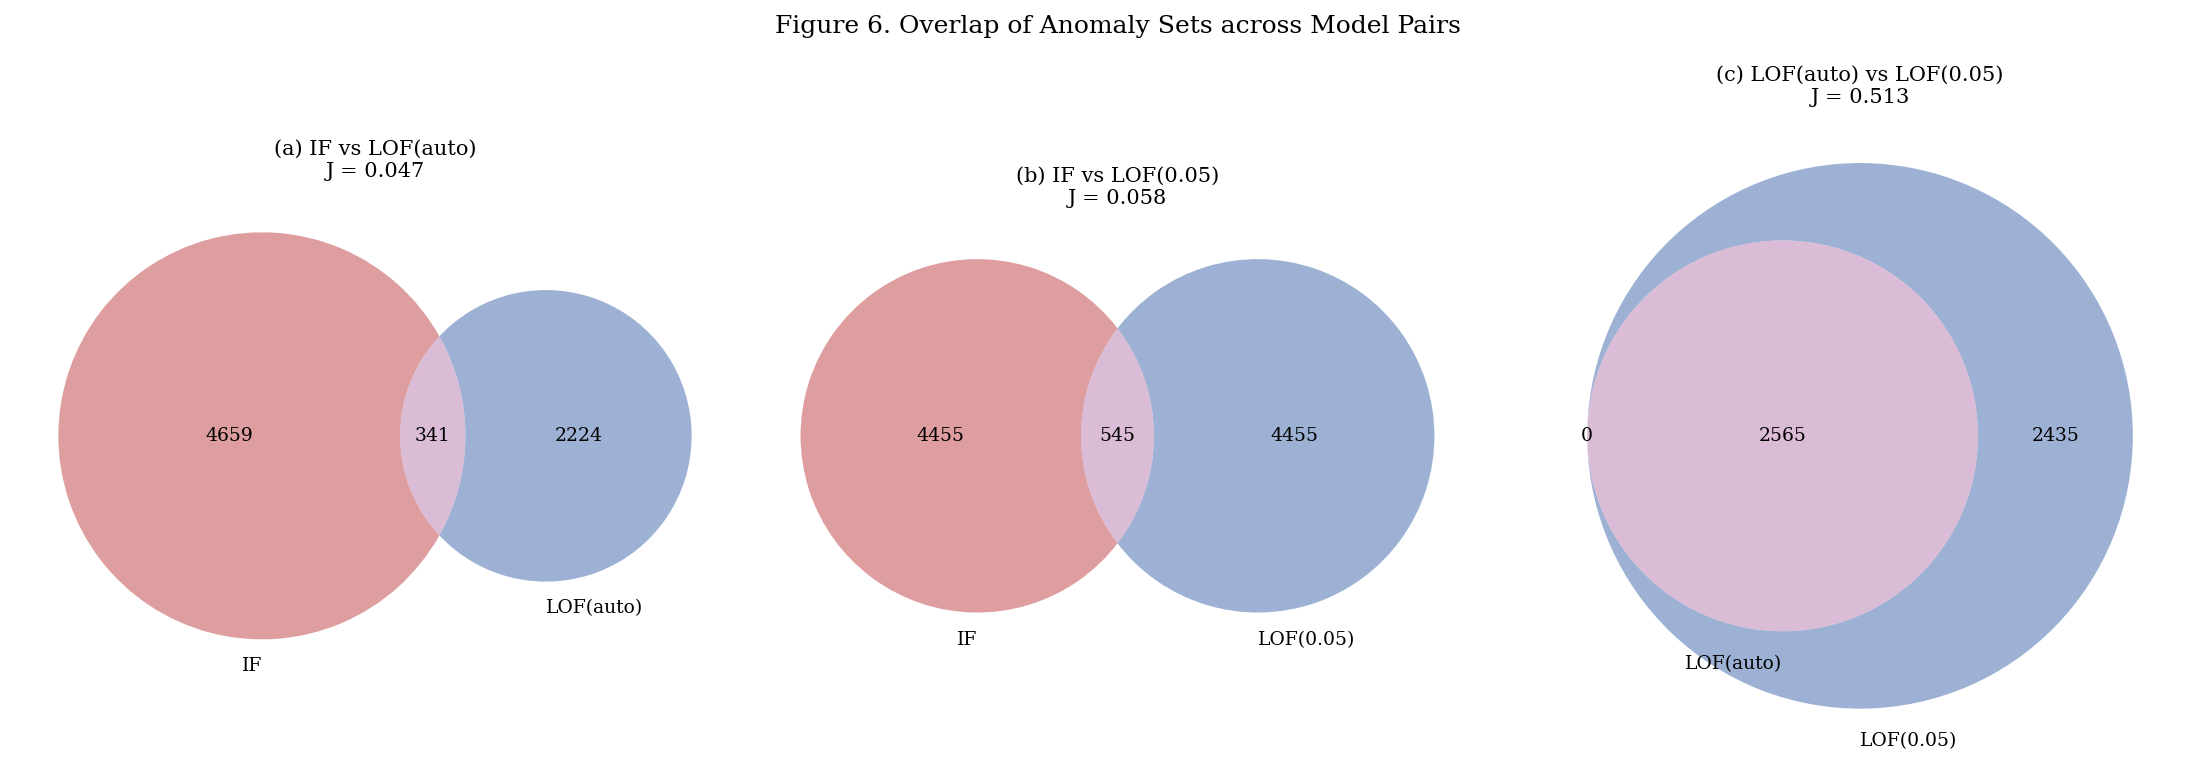

Saved Figure 6 -> nb04_fig6_venn.png (300 dpi)
Panel (c) shows complete containment: LOF(auto) has no private region, because it is the same score vector thresholded more strictly.


In [9]:
# Cell 09 — Plot: Figure 6, Venn Diagrams of Anomaly-Set Overlap

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

venn_specs = [
    (axes[0], S_IF, S_LOF_AUTO, ("IF", "LOF(auto)"), "(a) IF vs LOF(auto)"),
    (axes[1], S_IF, S_LOF_05, ("IF", "LOF(0.05)"), "(b) IF vs LOF(0.05)"),
    (axes[2], S_LOF_AUTO, S_LOF_05, ("LOF(auto)", "LOF(0.05)"), "(c) LOF(auto) vs LOF(0.05)"),
]

for ax, a, b, labels, title in venn_specs:
    v = venn2([a, b], set_labels=labels, ax=ax,
              set_colors=("#C44E52", "#4C72B0"), alpha=0.55)
    ax.set_title(f"{title}\nJ = {jaccard(a, b):.3f}", fontsize=10)
    for text in (v.set_labels or []):
        if text:
            text.set_fontsize(9)
    for text in (v.subset_labels or []):
        if text:
            text.set_fontsize(9)

fig.suptitle("Figure 6. Overlap of Anomaly Sets across Model Pairs", y=1.02)
fig.tight_layout()
fig6_path = FIGURES / "nb04_fig6_venn.png"
fig.savefig(fig6_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved Figure 6 -> {fig6_path.name} (300 dpi)")
print("Panel (c) shows complete containment: LOF(auto) has no private region, because it is "
      "the same score vector thresholded more strictly.")

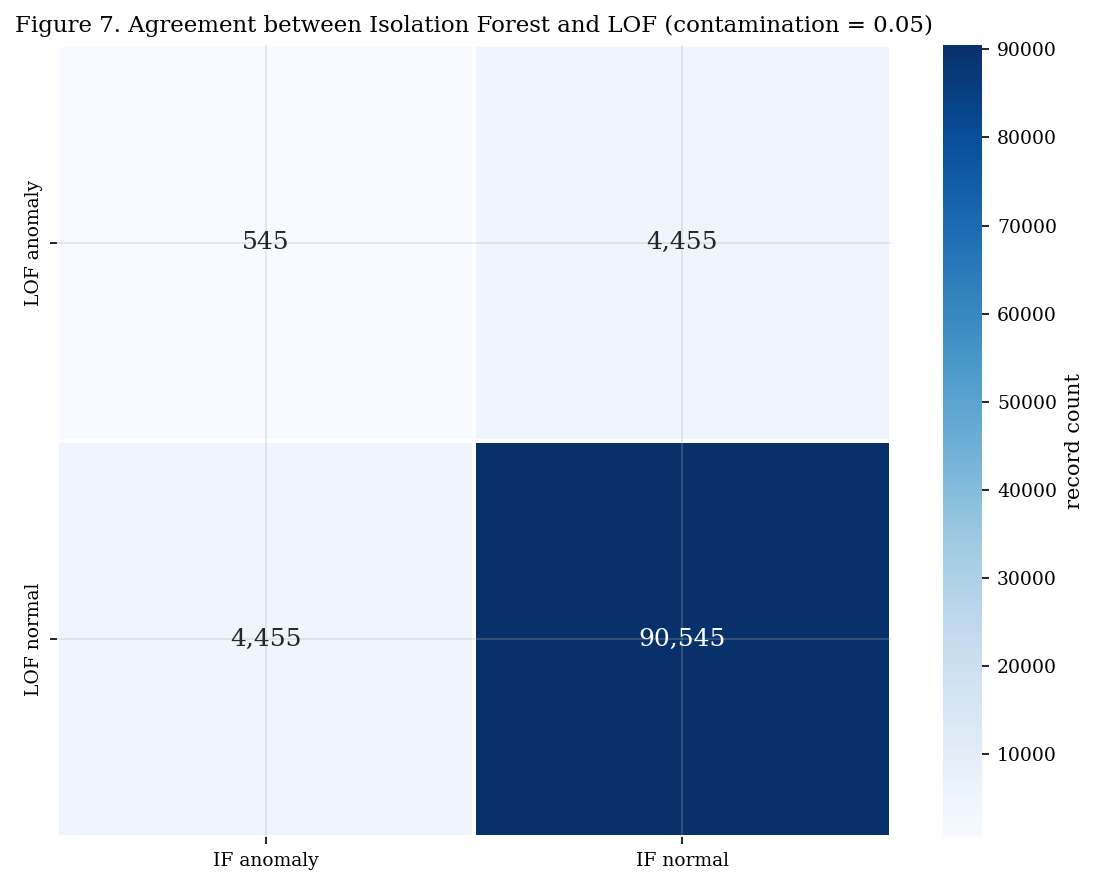

             IF anomaly  IF normal
LOF anomaly         545       4455
LOF normal         4455      90545

Margins: IF total 5,000 | LOF total 5,000 | N 100,000
Saved Figure 7 -> nb04_fig7_contingency.png (300 dpi)

Both margins reconcile with Table 1 (5,000 each). The submitted Figure 7 did not:
its cells implied 1,000 LOF anomalies. Use this version, not the published one.


In [10]:
# Cell 10 — Plot: Figure 7, IF x LOF(0.05) Contingency
# Recomputed, not ported. The submitted Figure 7 showed cell counts (4672/328/94328/672)
# that imply 1,000 LOF anomalies -- irreconcilable with Table 2's 5,000.

n11 = len(S_IF & S_LOF_05)
n10 = len(S_IF - S_LOF_05)
n01 = len(S_LOF_05 - S_IF)
n00 = N_TOTAL - n11 - n10 - n01
assert n11 + n10 + n01 + n00 == N_TOTAL, "Contingency table does not sum to N"

contingency = pd.DataFrame(
    [[n11, n10], [n01, n00]],
    index=["LOF anomaly", "LOF normal"],
    columns=["IF anomaly", "IF normal"],
)

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(contingency, annot=True, fmt=",d", cmap="Blues", linewidths=1.0,
            cbar_kws={"label": "record count"}, annot_kws={"fontsize": 12}, ax=ax)
ax.set_title("Figure 7. Agreement between Isolation Forest and LOF (contamination = 0.05)")
fig.tight_layout()
fig7_path = FIGURES / "nb04_fig7_contingency.png"
fig.savefig(fig7_path, dpi=300, bbox_inches="tight")
plt.show()

print(contingency.to_string())
print(f"\nMargins: IF total {n11 + n10:,} | LOF total {n11 + n01:,} | N {N_TOTAL:,}")
print(f"Saved Figure 7 -> {fig7_path.name} (300 dpi)")
print(
    "\nBoth margins reconcile with Table 1 (5,000 each). The submitted Figure 7 did not:\n"
    "its cells implied 1,000 LOF anomalies. Use this version, not the published one."
)

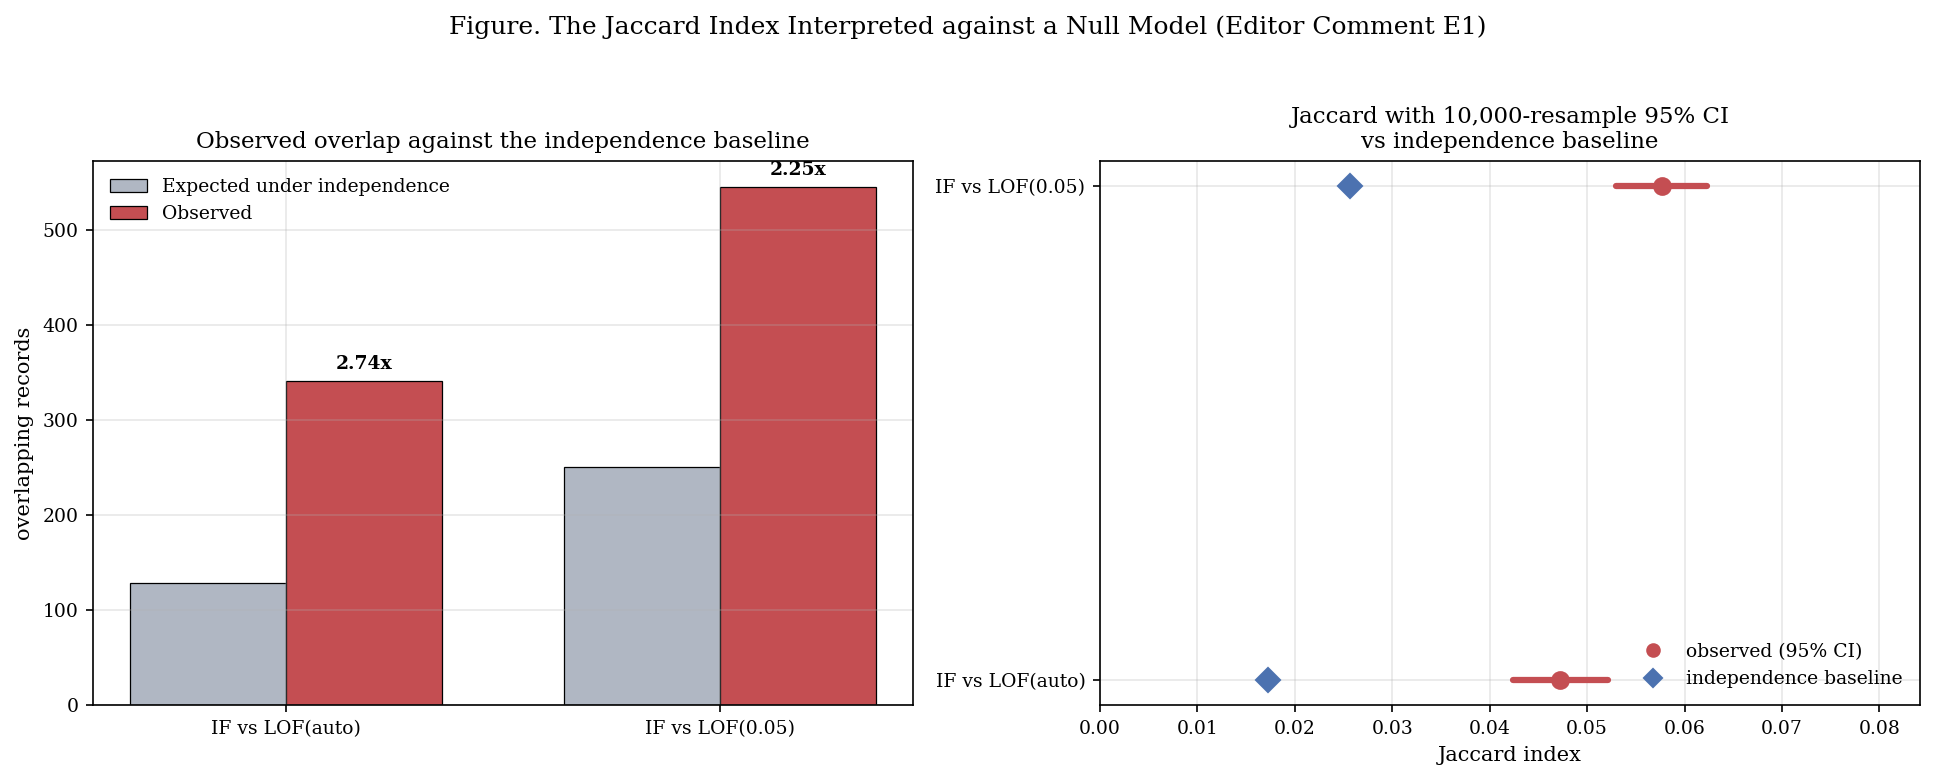

Saved -> nb04_fig_null_model.png (300 dpi)


In [11]:
# Cell 11 — Plot: Observed vs Independence Baseline (E1)

valid_pairs = null_model[null_model["Independence null valid"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: observed vs expected overlap counts
x = np.arange(len(valid_pairs))
w = 0.36
axes[0].bar(x - w / 2, valid_pairs["Expected Overlap (null)"], w,
            label="Expected under independence", color="#B0B7C3", edgecolor="black", linewidth=0.6)
axes[0].bar(x + w / 2, valid_pairs["Observed Overlap"], w,
            label="Observed", color="#C44E52", edgecolor="black", linewidth=0.6)
for i, (_, r) in enumerate(valid_pairs.iterrows()):
    axes[0].text(i + w / 2, r["Observed Overlap"] + 12, f"{r['Enrichment (x chance)']:.2f}x",
                 ha="center", fontsize=9, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(valid_pairs["Model Pair"], fontsize=9)
axes[0].set_ylabel("overlapping records")
axes[0].set_title("Observed overlap against the independence baseline")
axes[0].legend(frameon=False)

# Right: Jaccard with bootstrap CI against the null
boot_valid = bootstrap[bootstrap["Model Pair"].isin(valid_pairs["Model Pair"])]
y = np.arange(len(boot_valid))
for i, (_, r) in enumerate(boot_valid.iterrows()):
    axes[1].plot([r["CI lower (2.5%)"], r["CI upper (97.5%)"]], [i, i],
                 color="#C44E52", linewidth=3, solid_capstyle="round")
    axes[1].plot(r["Jaccard"], i, "o", color="#C44E52", ms=8, zorder=3)
    axes[1].plot(r["Null Jaccard"], i, "D", color="#4C72B0", ms=8, zorder=3)
axes[1].set_yticks(y)
axes[1].set_yticklabels(boot_valid["Model Pair"], fontsize=9)
axes[1].set_xlabel("Jaccard index")
axes[1].set_title(f"Jaccard with {N_BOOT:,}-resample 95% CI\nvs independence baseline")
axes[1].plot([], [], "o", color="#C44E52", label="observed (95% CI)")
axes[1].plot([], [], "D", color="#4C72B0", label="independence baseline")
axes[1].legend(frameon=False, loc="lower right")
axes[1].set_xlim(0, max(boot_valid["CI upper (97.5%)"]) * 1.35)

fig.suptitle("Figure. The Jaccard Index Interpreted against a Null Model (Editor Comment E1)", y=1.03)
fig.tight_layout()
null_fig_path = FIGURES / "nb04_fig_null_model.png"
fig.savefig(null_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved -> {null_fig_path.name} (300 dpi)")

---
## Section 4 — Persistence & Handover

In [12]:
# Cell 12 — Export: Tables & JSON Handshake (NB04 -> NB05/NB07)

table2_path = TABLES / "nb04_table2_jaccard_overlap.csv"
null_path = TABLES / "nb04_jaccard_null_model.csv"
boot_path = TABLES / "nb04_jaccard_bootstrap_ci.csv"

table2.to_csv(table2_path, index=False)
null_model.to_csv(null_path, index=False)
bootstrap.to_csv(boot_path, index=False)

summary = {
    "notebook": "NB04",
    "status": "SUCCESS",
    "timestamp": pd.Timestamp.now().isoformat(),
    "environment": ENVIRONMENT,
    "seed": SEED,
    "addresses_comment": "E1 (plus manuscript Table 2, Figures 6-7)",
    "inputs_consumed": [
        "outputs/notebook_exports/summary_NB02.json",
        "data/processed/anomaly_labels.parquet",
        "data/processed/features_raw.parquet",
    ],
    "outputs": {
        "table2": "outputs/tables/nb04_table2_jaccard_overlap.csv",
        "null_model": "outputs/tables/nb04_jaccard_null_model.csv",
        "bootstrap_ci": "outputs/tables/nb04_jaccard_bootstrap_ci.csv",
        "consensus_set": "data/processed/consensus_anomalies.parquet",
        "figure_6": "outputs/figures/nb04_fig6_venn.png",
        "figure_7": "outputs/figures/nb04_fig7_contingency.png",
        "figure_null_model": "outputs/figures/nb04_fig_null_model.png",
    },
    "key_results": {
        "overlap_if_lof_auto": int(len(S_IF & S_LOF_AUTO)),
        "overlap_if_lof_05": int(len(S_IF & S_LOF_05)),
        "overlap_lof_auto_lof_05": int(len(S_LOF_AUTO & S_LOF_05)),
        "jaccard_if_lof_auto": round(jaccard(S_IF, S_LOF_AUTO), 5),
        "jaccard_if_lof_05": round(jaccard(S_IF, S_LOF_05), 5),
        "jaccard_lof_auto_lof_05": round(jaccard(S_LOF_AUTO, S_LOF_05), 5),
        "lof_auto_nested_in_lof_05": bool(NESTED),
        "consensus_set_size": int(len(df_consensus)),
        "null_model": null_model.to_dict(orient="records"),
        "bootstrap_ci": bootstrap.to_dict(orient="records"),
        "n_bootstrap": N_BOOT,
    },
    "assertions": {
        "upstream_nb02_verified": True,
        "table2_overlap_parity": True,
        "lof_auto_strict_subset_of_lof_05": bool(NESTED),
        "consensus_set_is_545": len(df_consensus) == 545,
        "contingency_sums_to_N": True,
    },
    "downstream_note": (
        "NB05 consumes data/processed/consensus_anomalies.parquet (545 records, with "
        "record_index giving position in features_raw.parquet) for its case-profile table. "
        "NB07 renders Figures 6, 7 and the null-model figure. "
        "MANUSCRIPT ACTION: the E1 result reverses the reading of section 3.3 -- observed "
        "overlap exceeds the independence baseline by roughly 2.2x to 2.7x, so 'low Jaccard "
        "therefore the models disagree' is not supported. Complementarity still holds, but "
        "the wording in section 3.3 and the abstract must be revised and the change disclosed "
        "in the cover letter."
    ),
}

summary_path = EXPORTS / "summary_NB04.json"
with open(summary_path, "w", encoding="utf-8") as fh:
    json.dump(summary, fh, indent=2, default=str)

failed = [k for k, v in summary["assertions"].items() if not v]
if failed:
    raise AssertionError(f"Handshake written but assertions failed: {failed}")

print(f"{table2_path.name}")
print(f"{null_path.name}")
print(f"{boot_path.name}")
print(f"{summary_path.relative_to(BASE)}")
print(f"\nAll {len(summary['assertions'])} assertions passed.")

nb04_table2_jaccard_overlap.csv
nb04_jaccard_null_model.csv
nb04_jaccard_bootstrap_ci.csv
outputs/notebook_exports/summary_NB04.json

All 5 assertions passed.


---
## NB04 Complete

| Pair | Overlap | Published | Jaccard | Null J | Enrichment |
|---|---|---|---|---|---|
| IF vs LOF(auto) | 341 | 341 ✅ | 0.047 | 0.017 | **2.74×** |
| IF vs LOF(0.05) | 545 | 545 ✅ | 0.058 | 0.026 | **2.25×** |
| LOF(auto) vs LOF(0.05) | 2,565 | 2,565 ✅ | 0.513 | — | nested, null N/A |

Table 2 reproduces exactly, and `LOF(auto) ⊂ LOF(0.05)` is confirmed.

**The E1 finding, stated carefully.** The observed overlap between IF and LOF is roughly
**2.2–2.7× the independence baseline**, at Z ≈ 19.5 with bootstrap intervals well clear of
the null. The manuscript currently reads a low Jaccard as the models disagreeing; that
inference does not hold, because a low Jaccard is what any pair of small subsets of a large
population produces by default. The algorithms agree substantially more than chance while
each retains a large private subset — which is a **stronger** statement of complementarity
than the one in the submitted paper, but a different one.

§3.3 and the abstract need revising, and the change must be disclosed in the cover letter.
This is the reinterpretation you approved in principle; the numbers now exist to support it.

**Next:** return `summary_NB04.json`, the three tables, three figures and
`consensus_anomalies.parquet`, then generate **NB05** (`05_validation_synthetic.ipynb`,
editor comment C1) — synthetic injection with precision/recall/F1, plus descriptive case
profiles of these 545 consensus records.

NB05 needs decisions first: injection rate, injection mechanism, the clean-subset definition
and the random seed. All must be fixed constants logged in `REPRODUCIBILITY.md` §7.